<a href="https://colab.research.google.com/github/brittanybee-alt/DataScienceGuidedCapstone/blob/master/Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import cross_validate

In [21]:
expected_model_version = '1.0'
model_path = '/content/sample_data/ski_resort_pricing_model.pkl'
if os.path.exists(model_path):
  with open(model_path, 'rb') as f:
    model = pickle.load(f)
  if model.version != expected_model_version:
    print("Expected model version doesn't match version loaded")
  if model.sklearn_version != sklearn_version:
    print("Warning: model created under different sklearn version")
else:
  print("Expected model not found")

In [22]:
ski_data = pd.read_csv('/content/sample_data/ski_data_step3_features.csv')

In [23]:
big_mountain = ski_data[ski_data.Name == 'Big Mountain Resort']

In [24]:
big_mountain.T

,124
Name,Big Mountain Resort
Region,Montana
state,Montana
summit_elev,6817
vertical_drop,2353
base_elev,4464
trams,0
fastSixes,0
fastQuads,3
quad,2


In [25]:
X = ski_data.loc[ski_data.Name != "Big Mountain Resort", model.X_columns]
y = ski_data.loc[ski_data.Name != "Big Mountain Resort", 'AdultWeekend']

In [26]:
len(X), len(y)

(276, 276)

In [27]:
model.fit(X, y)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', None),
                ('randomforestregressor',
                 RandomForestRegressor(n_estimators=69, random_state=47))])

In [28]:
cv_results = cross_validate(model, X, y, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

In [29]:
cv_results['test_score']

array([-12.09690217,  -9.30247694, -11.41595784,  -8.10096706,
       -11.04942819])

In [31]:
mae_mean, mae_std = np.mean(-1 * cv_results['test_score']), np.std(-1 * cv_results['test_score'])
mae_mean, mae_std

(np.float64(10.393146442687748), np.float64(1.4712769116280346))

In [32]:
X_bm = ski_data.loc[ski_data.Name == "Big Mountain Resort", model.X_columns]
y_bm = ski_data.loc[ski_data.Name == "Big Mountain Resort", 'AdultWeekend']

In [33]:
bm_pred = model.predict(X_bm).item()

In [35]:
y_bm = y_bm.values.item()

In [37]:
print(f'Big Mountain Resort modelled price is ${bm_pred:.2f}, actual price is ${y_bm:.2f}.')
print(f'Even with the expected mean absolute error of ${mae_mean:.2f}, this suggests there is room for an increase.')

Big Mountain Resort modelled price is $95.87, actual price is $81.00.
Even with the expected mean absolute error of $10.39, this suggests there is room for an increase.


In [38]:
def plot_compare(feat_name, description, state=None, figsize=(10, 5)):
  """Graphically compare distributions of features.

  Plot histogram of values for all resorts and reference line to mark Big Mountain's positions.

  Arguments:
  feat_name - the feature column name in the data
  decription - text description of the feature
  state - select a specific state (None for all states)
  figsize - (optional) figure size
  """

  plt.subplots(figsize=figsize)
  if state is None:
      ski_x = ski_data[feat_name]
  else:
      ski_x = ski_data.loc[ski_data.state == state, feat_name]
  ski_x = ski_x[np.isfinite(ski_x)]
  plt.hist(ski_x, bins=30)
  plt.axvline(x=big_mountain[feat_name].values, c='r', ls='--', alpha=0.8, label='Big Mountain')
  plt.xlabel(description)
  plt.ylabel('frequency')
  plt.title(description + 'distribution for resorts in market share')
  plt.legend()

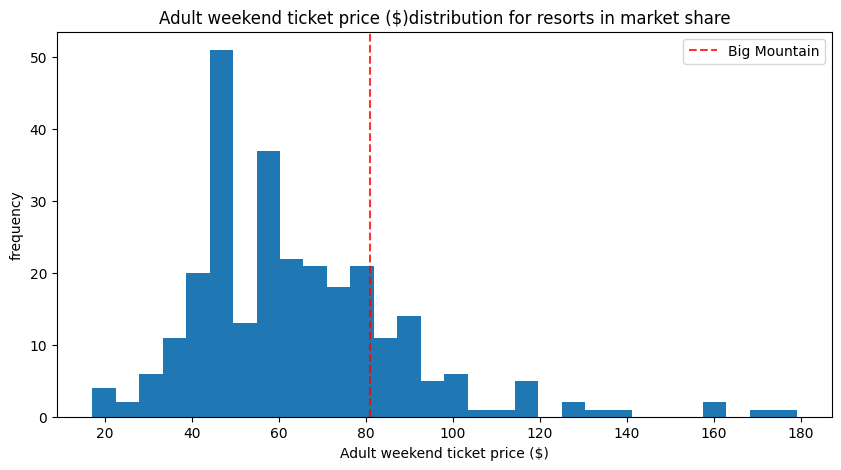

In [39]:
plot_compare('AdultWeekend', 'Adult weekend ticket price ($)')

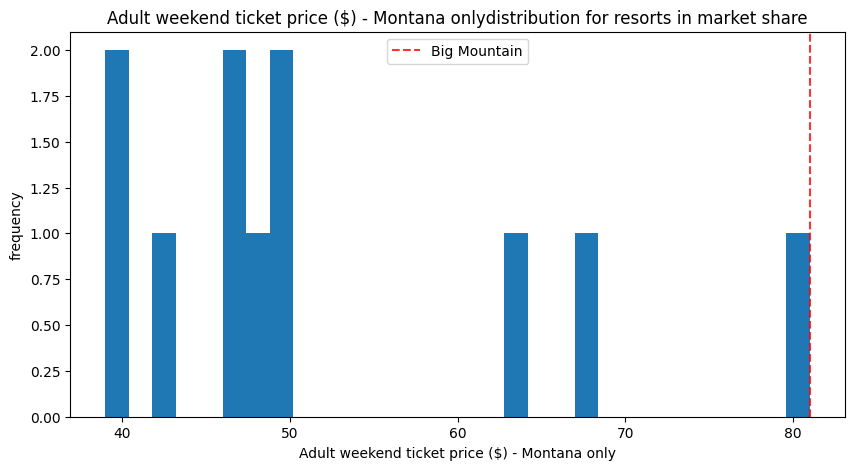

In [41]:
plot_compare('AdultWeekend', 'Adult weekend ticket price ($) - Montana only', state='Montana')

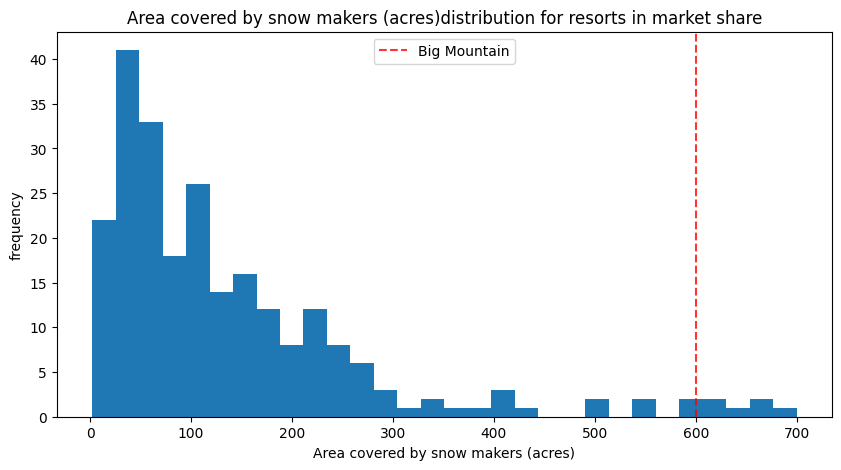

In [42]:
plot_compare('Snow Making_ac', 'Area covered by snow makers (acres)')

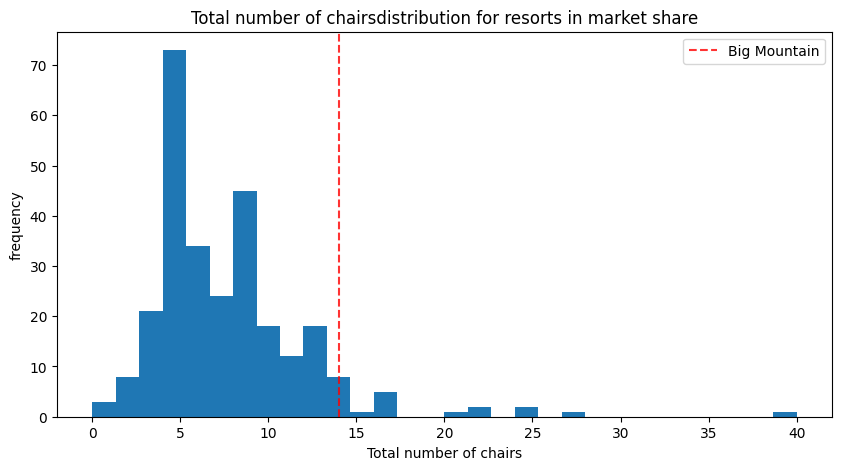

In [43]:
plot_compare('total_chairs', 'Total number of chairs')

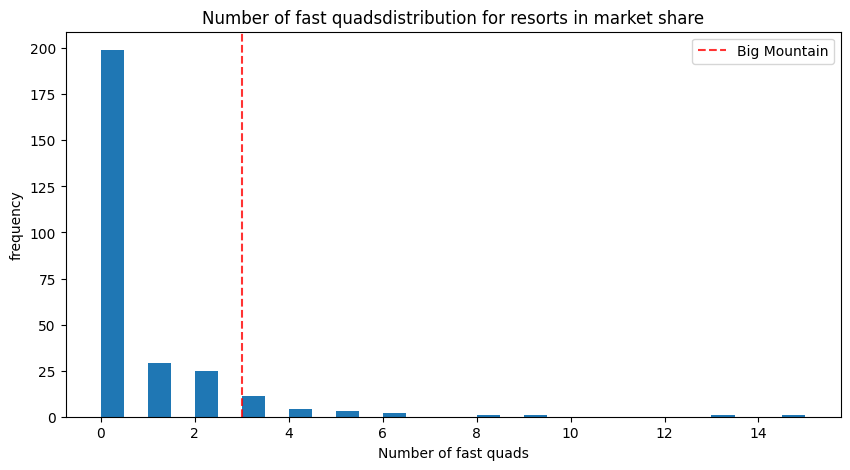

In [44]:
plot_compare('fastQuads', 'Number of fast quads')

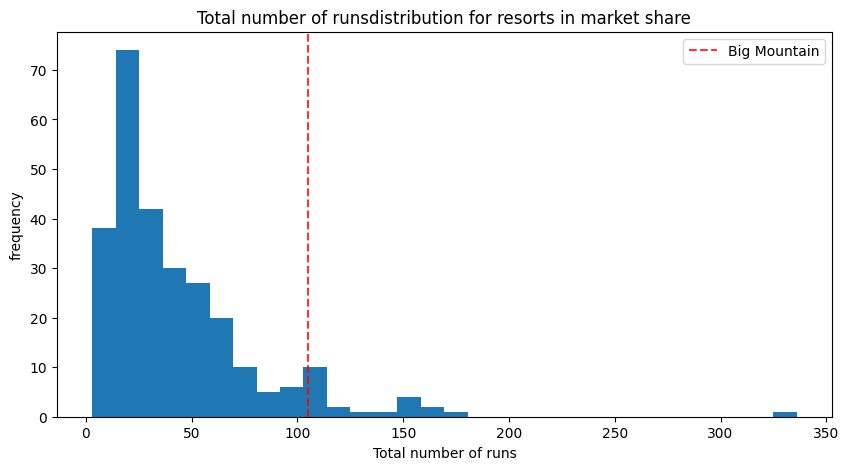

In [45]:
plot_compare('Runs', 'Total number of runs')

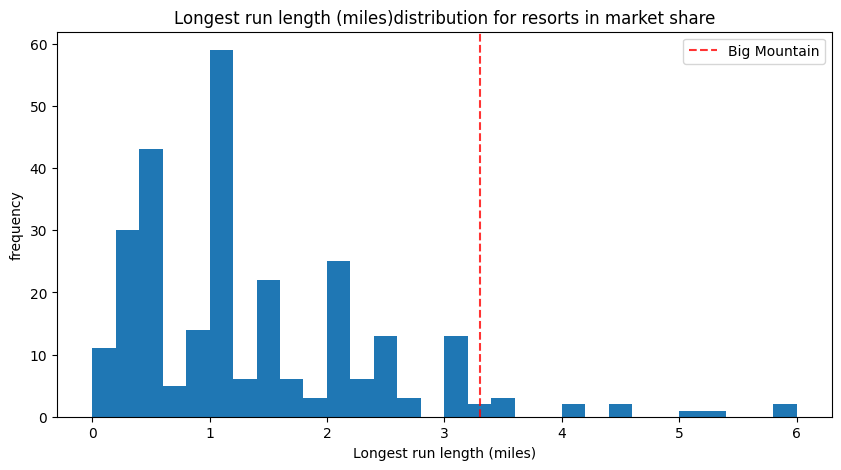

In [46]:
plot_compare('LongestRun_mi', 'Longest run length (miles)')

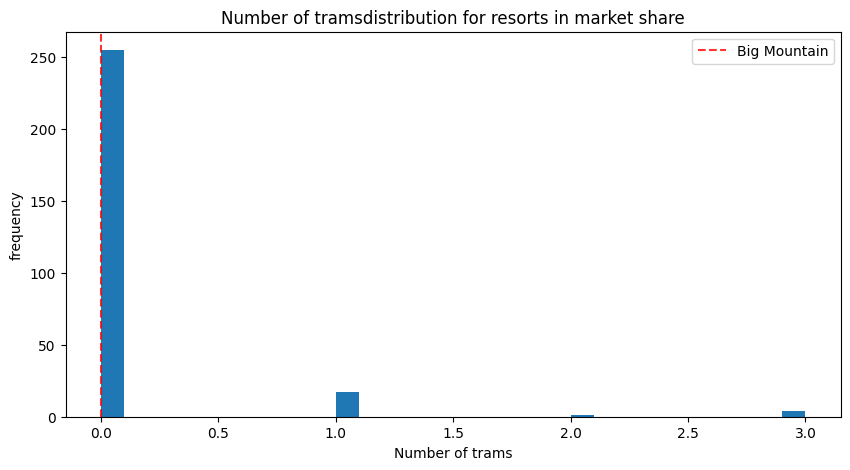

In [47]:
plot_compare('trams', 'Number of trams')

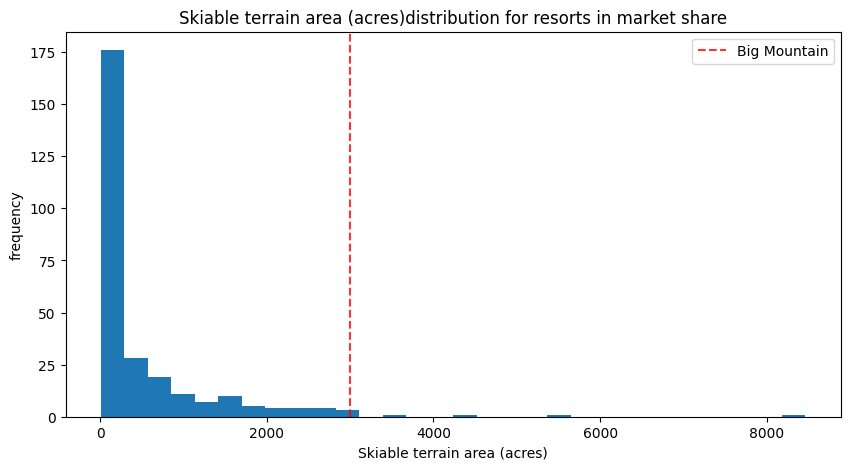

In [48]:
plot_compare('SkiableTerrain_ac', 'Skiable terrain area (acres)')

In [49]:
expected_visitors = 350_000

In [50]:
all_feats = ['vertical_drop', 'Snow Making_ac', 'total_chairs', 'fastQuads', 'Runs', 'LongestRun_mi', 'trams', 'SkiableTerrain_ac']
big_mountain[all_feats]

,vertical_drop,Snow Making_ac,total_chairs,fastQuads,Runs,LongestRun_mi,trams,SkiableTerrain_ac
124,2353,600.0,14,3,105.0,3.3,0,3000.0


In [51]:
def predict_increase(features, deltas):
    """Increase in modelled ticket price by applying delta to feature.

    Arguments:
    features - list, names of the features in thee ski_data dataframe to change
    deltas - list, the amounts by which to increase the values of the features

    Outputs:
    Amount of increase in the predicted ticket price
    """

    bm2 = X_bm.copy()
    for f, d in zip (features, deltas):
        bm2[f] += d
    return model.predict(bm2).item() - model.predict(X_bm).item()

In [52]:
[i for i in range(-1, -11, -1)]

[-1, -2, -3, -4, -5, -6, -7, -8, -9, -10]

In [55]:
runs_delta = [i for i in range (-1, -11, -1)]
price_deltas = [predict_increase(['Runs'], [delta]) for delta in runs_delta]

In [56]:
price_deltas

[0.0,
 -0.4057971014492807,
 -0.6666666666666714,
 -0.6666666666666714,
 -0.6666666666666714,
 -1.2608695652173907,
 -1.2608695652173907,
 -1.2608695652173907,
 -1.7101449275362341,
 -1.8115942028985472]

[Text(0.5, 0, 'Runs closed'),
 Text(0, 0.5, 'Revenue ($)'),
 Text(0.5, 1.0, 'Revenue')]

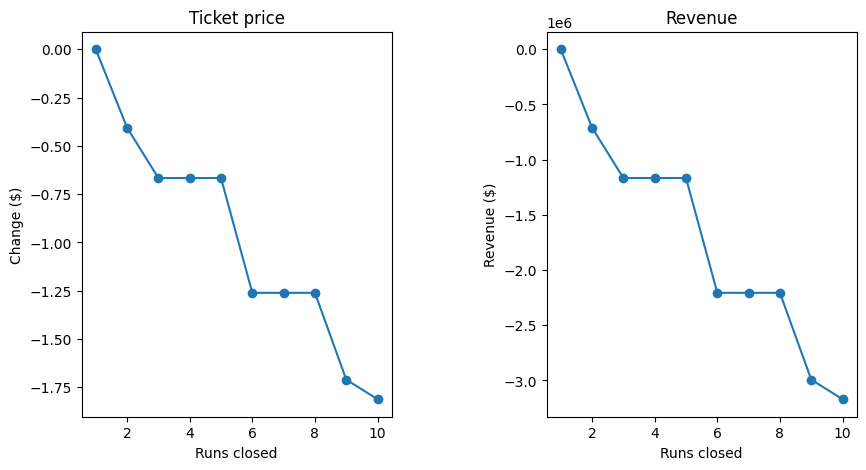

In [57]:
runs_closed = [-1 * delta for delta in runs_delta]
fig, ax  = plt.subplots(1, 2, figsize=(10, 5))
fig.subplots_adjust(wspace=0.5)
ax[0].plot(runs_closed, price_deltas, 'o-')
ax[0].set(xlabel='Runs closed', ylabel='Change ($)', title='Ticket price')
revenue_deltas = [5 * expected_visitors * delta for delta in price_deltas]
ax[1].plot(runs_closed, revenue_deltas, 'o-')
ax[1].set(xlabel='Runs closed', ylabel='Revenue ($)', title='Revenue')

In [58]:
ticket2_increase = predict_increase(['Runs', 'vertical_drop', 'total_chairs'], [1, 150, 1])
revenue2_increase = 5 * expected_visitors * ticket2_increase

In [59]:
print(f'This scenario increases support for ticket price by ${ticket2_increase:.2f}')
print(f'Over the season, this could be expected to amount to ${revenue2_increase:.0f}')

This scenario increases support for ticket price by $1.99
Over the season, this could be expected to amount to $3474638


In [61]:
ticket3_increase = predict_increase(['Runs', 'vertical_drop', 'total_chairs', 'Snow Making_ac'], [1, 150, 1, 2])
revenue3_increase = 5 * expected_visitors * ticket3_increase

In [63]:
print(f'This scenario increases support for ticket price by ${ticket3_increase:.2f}')
print(f'Over the season, this could be expected to amount to ${revenue3_increase:.0f}')

This scenario increases support for ticket price by $1.99
Over the season, this could be expected to amount to $3474638


In [64]:
predict_increase(['LongestRun_mi', 'Snow Making_ac'], [0.2, 4])

0.0